# RQ1 Phase 1 Analysis: Correctness and Failure Structure

This notebook performs the analyses described for **RQ1: Correctness and failure structure**.

It covers:

1. data loading and validation;
2. derived correctness outcomes;
3. full-correctness descriptives;
4. normalized failure frequencies by failure class;
5. one-way ANOVA and Tukey HSD post-hoc comparisons;
6. partial eta squared and Hedges' g with bootstrap confidence intervals;
7. negative binomial regression for hidden-test failures;
8. G2/G3 prompt--specification alignment analyses;
9. secondary prompt-behavior analyses by failure class;
10. export of CSV and LaTeX-ready tables.

The notebook assumes the uploaded CSV files are in the same directory as this notebook or in `/Data/`.

In [ ]:
# ============================================================
# 0. Imports and global settings
# ============================================================
from pathlib import Path
import ast
import itertools
import warnings

import numpy as np
import pandas as pd

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

RANDOM_SEED = 2026

# Increase N_BOOT to 3000 or 5000 for final camera-ready estimates.
N_BOOT = 1000

# Set to True only when statsmodels should estimate NB dispersion.
ESTIMATE_NB_ALPHA = False

rng = np.random.default_rng(RANDOM_SEED)


# ============================================================
# 1. Project paths
# ============================================================
def find_project_root(
    start_path: Path | None = None,
    data_folder: str = "data"
) -> Path:
    """
    Find the project root by searching the current directory and
    its parent directories for a folder named `data`.
    """
    start_path = (start_path or Path.cwd()).resolve()

    for directory in [start_path, *start_path.parents]:
        if (directory / data_folder).is_dir():
            return directory

    raise FileNotFoundError(
        f"Could not find a '{data_folder}' folder in "
        f"'{start_path}' or any of its parent directories."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR = Path("rq1_outputs")

OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Using data directory: {DATA_DIR}")
print(f"Writing results to: {OUT_DIR}")

In [5]:
# ============================================================
# 1. Load datasets
# ============================================================
FILES = {
    "rq1": "RQ1_phase1.csv",                    # pre-merged RQ1 analysis file
    "phase1_raw": "dataset_phase1.csv",         # raw Phase 1 survey/outcome data
    "phase2_raw": "dataset_phase2.csv",         # raw Phase 2 data; loaded for completeness
    "failure_modes": "failure_modes_phase1.csv",# failure class labels per participant
    "hidden_tests": "hidden_tests_phase1.csv",  # hidden-test pass/fail lists
}

def read_csv_checked(filename):
    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    df = pd.read_csv(path)
    print(f"{filename}: {df.shape[0]} rows x {df.shape[1]} columns")
    return df

rq1 = read_csv_checked(FILES["rq1"])
phase1_raw = read_csv_checked(FILES["phase1_raw"])
phase2_raw = read_csv_checked(FILES["phase2_raw"])
failure_modes = read_csv_checked(FILES["failure_modes"])
hidden_tests = read_csv_checked(FILES["hidden_tests"])

print("\nRQ1 columns:")
print(rq1.columns.tolist())

RQ1_phase1.csv: 72 rows x 14 columns
dataset_phase1.csv: 72 rows x 30 columns
dataset_phase2.csv: 72 rows x 31 columns
failure_modes_phase1.csv: 72 rows x 6 columns
hidden_tests_phase1.csv: 72 rows x 8 columns

RQ1 columns:
['participant_id', 'task', 'spec_condition', 'python_skill', 'llm_familiarity', 'prompt_count', 'total_prompt_length', 'prompt_alignment', 'constraints_in_prompt', 'edge_cases_in_prompt', 'tests_requested', 'passed_tests', 'failure_count', 'failure_diversity']


In [6]:
# ============================================================
# 2. Validate expected columns and standardize names
# ============================================================
required_rq1_cols = [
    "participant_id", "task", "spec_condition", "python_skill", "llm_familiarity",
    "prompt_count", "total_prompt_length", "prompt_alignment", "constraints_in_prompt",
    "edge_cases_in_prompt", "tests_requested", "passed_tests", "failure_count", "failure_diversity"
]
missing = [c for c in required_rq1_cols if c not in rq1.columns]
if missing:
    raise ValueError(f"RQ1 file is missing required columns: {missing}")

# Standardize important columns.
df = rq1.copy()
df["spec_condition"] = pd.Categorical(df["spec_condition"], categories=["G1", "G2", "G3"], ordered=True)
df["task"] = df["task"].astype(str)

# Numeric coercion.
num_cols = [
    "python_skill", "llm_familiarity", "prompt_count", "total_prompt_length",
    "prompt_alignment", "constraints_in_prompt", "edge_cases_in_prompt",
    "tests_requested", "passed_tests", "failure_count", "failure_diversity"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Total hidden tests and full correctness.
df["total_hidden_tests"] = df["passed_tests"] + df["failure_count"]
df["observed_pass_rate"] = df["passed_tests"] / df["total_hidden_tests"]
df["full_correctness"] = (df["failure_count"] == 0).astype(int)

# Basic checks.
checks = pd.DataFrame({
    "n_rows": [len(df)],
    "n_participants": [df["participant_id"].nunique()],
    "conditions": [", ".join(df["spec_condition"].dropna().astype(str).unique())],
    "tasks": [", ".join(sorted(df["task"].dropna().astype(str).unique()))],
    "hidden_tests_min": [df["total_hidden_tests"].min()],
    "hidden_tests_max": [df["total_hidden_tests"].max()],
})
display(checks)

if df["participant_id"].duplicated().any():
    print("Warning: duplicate participant_id values detected in RQ1 file.")

if df["total_hidden_tests"].nunique() > 1:
    print("Note: total hidden tests differ across rows/tasks. Normalized rates will account for this.")

,n_rows,n_participants,conditions,tasks,hidden_tests_min,hidden_tests_max
0,72,72,"G1, G2, G3","A, B",33,33


## Derived failure-mode variables

The raw `failure_modes_phase1.csv` file contains lists of failure categories for each participant. This section parses those lists and computes:

- per-participant failure count by category;
- per-participant pass count by category;
- normalized failure frequency by category:  
  \[
  \text{NormFailFreq}_{i,c}=\frac{\#\text{failed tests}_{i,c}}{\#\text{failed tests}_{i,c}+\#\text{passed tests}_{i,c}}
  \]
- failure-mode diversity: the number of distinct failure categories appearing in a submission.

In [7]:
# ============================================================
# 3. Parse failure-mode categories and compute normalized frequencies
# ============================================================
def parse_list_cell(x):
    """Parse cells that look like Python lists; return an empty list for missing/invalid cells."""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    s = str(x).strip()
    if not s:
        return []
    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return [str(v) for v in val]
    except Exception:
        pass
    # fallback for semicolon-separated or comma-separated strings
    if ";" in s:
        return [v.strip() for v in s.split(";") if v.strip()]
    if "," in s:
        return [v.strip() for v in s.split(",") if v.strip()]
    return [s]

fm = failure_modes.copy()
fm["failed_list"] = fm["failed_categories"].apply(parse_list_cell)
fm["passed_list"] = fm["passed_categories"].apply(parse_list_cell)

all_categories = sorted(set(itertools.chain.from_iterable(fm["failed_list"])) | set(itertools.chain.from_iterable(fm["passed_list"])))
print("Failure categories:", all_categories)

for cat in all_categories:
    fm[f"fail_{cat}"] = fm["failed_list"].apply(lambda xs, c=cat: sum(x == c for x in xs))
    fm[f"pass_{cat}"] = fm["passed_list"].apply(lambda xs, c=cat: sum(x == c for x in xs))
    denom = fm[f"fail_{cat}"] + fm[f"pass_{cat}"]
    fm[f"norm_fail_{cat}"] = np.where(denom > 0, fm[f"fail_{cat}"] / denom, np.nan)

fm["failure_diversity_recomputed"] = fm["failed_list"].apply(lambda xs: len(set(xs)))
fm_small_cols = ["anon_id", "version", "specification", "Task", "failure_diversity_recomputed"] + \
                [f"fail_{c}" for c in all_categories] + [f"norm_fail_{c}" for c in all_categories]
fm_small = fm[fm_small_cols].copy()
fm_small = fm_small.rename(columns={"anon_id": "participant_id", "specification": "spec_condition", "Task": "task"})

# Merge into main df.
df = df.merge(
    fm_small.drop(columns=["version", "spec_condition", "task"], errors="ignore"),
    on="participant_id",
    how="left"
)

# Prefer RQ1's failure_diversity if present, but show a mismatch check.
if "failure_diversity_recomputed" in df.columns:
    mismatch = (df["failure_diversity"].round(6) != df["failure_diversity_recomputed"].round(6)).sum()
    print(f"Failure-diversity mismatches between RQ1 file and recomputed values: {mismatch}")

display(df.head())

Failure categories: ['AI', 'CO', 'EC', 'IV', 'TB']
Failure-diversity mismatches between RQ1 file and recomputed values: 0


,participant_id,task,spec_condition,python_skill,llm_familiarity,prompt_count,total_prompt_length,prompt_alignment,constraints_in_prompt,edge_cases_in_prompt,tests_requested,passed_tests,failure_count,failure_diversity,total_hidden_tests,observed_pass_rate,full_correctness,failure_diversity_recomputed,fail_AI,fail_CO,fail_EC,fail_IV,fail_TB,norm_fail_AI,norm_fail_CO,norm_fail_EC,norm_fail_IV,norm_fail_TB
0,S0001,A,G1,3.0,3.0,6.0,919.0,0.0,0.0,0.0,0.0,10,23,4,33,0.303030,0,4,5,8,5,5,0,0.555556,0.888889,0.555556,1.0,0.0
1,S0002,A,G1,NaN,NaN,7.0,229.0,0.0,0.0,0.0,0.0,12,21,4,33,0.363636,0,4,4,8,5,4,0,0.444444,0.888889,0.555556,0.8,0.0
2,S0003,A,G1,5.0,2.0,9.0,867.0,0.0,0.0,0.0,0.0,10,23,4,33,0.303030,0,4,5,9,4,5,0,0.555556,1.000000,0.444444,1.0,0.0
3,S0004,A,G1,1.0,3.0,NaN,NaN,0.0,0.0,0.0,0.0,5,28,5,33,0.151515,0,5,7,9,6,5,1,0.777778,1.000000,0.666667,1.0,1.0
4,S0005,A,G1,3.0,2.0,6.0,567.0,0.0,0.0,0.0,0.0,13,20,4,33,0.393939,0,4,4,8,4,4,0,0.444444,0.888889,0.444444,0.8,0.0


AI == UA

## Descriptive results

This section reports correctness and failure-structure summaries by specification condition.

In [8]:
# ============================================================
# 4. Descriptive tables by specification condition
# ============================================================
def mean_sd(series):
    return f"{series.mean():.2f} ({series.std(ddof=1):.2f})"

desc_rows = []
for cond, g in df.groupby("spec_condition", observed=True):
    desc_rows.append({
        "Spec.": cond,
        "n": len(g),
        "Passed tests, mean (SD)": mean_sd(g["passed_tests"]),
        "Failure count, mean (SD)": mean_sd(g["failure_count"]),
        "Full correct, n (%)": f"{int(g['full_correctness'].sum())} ({100*g['full_correctness'].mean():.2f}%)",
        "Failure diversity, mean (SD)": mean_sd(g["failure_diversity"]),
        "Prompt alignment, mean (SD)": mean_sd(g["prompt_alignment"]),
    })

desc_by_condition = pd.DataFrame(desc_rows)
display(desc_by_condition)

desc_by_condition.to_csv(OUT_DIR / "rq1_descriptives_by_condition.csv", index=False)

,Spec.,n,"Passed tests, mean (SD)","Failure count, mean (SD)","Full correct, n (%)","Failure diversity, mean (SD)","Prompt alignment, mean (SD)"
0,G1,24,11.46 (2.41),21.54 (2.41),0 (0.00%),4.04 (0.20),0.00 (0.00)
1,G2,24,13.33 (2.28),19.67 (2.28),0 (0.00%),4.00 (0.00),0.45 (0.33)
2,G3,24,21.62 (8.23),11.38 (8.23),1 (4.17%),3.21 (1.22),0.60 (0.26)


In [9]:
# ============================================================
# 5. Normalized failure frequencies by class and condition
# ============================================================
norm_cols = [f"norm_fail_{c}" for c in all_categories]
fail_count_cols = [f"fail_{c}" for c in all_categories]

norm_fail_by_condition = (
    df.groupby("spec_condition", observed=True)[norm_cols]
      .agg(["mean", "std", "count"])
)

# Flatten columns for export.
norm_fail_by_condition.columns = [f"{col.replace('norm_fail_', '')}_{stat}" for col, stat in norm_fail_by_condition.columns]
norm_fail_by_condition = norm_fail_by_condition.reset_index()

display(norm_fail_by_condition)
norm_fail_by_condition.to_csv(OUT_DIR / "rq1_normalized_failure_frequencies_by_condition.csv", index=False)

# More compact paper table: mean normalized failure frequency in percent.
compact_norm = df.groupby("spec_condition", observed=True)[norm_cols].mean().reset_index()
compact_norm = compact_norm.rename(columns={c: c.replace("norm_fail_", "") for c in norm_cols})
for c in all_categories:
    compact_norm[c] = (compact_norm[c] * 100).round(2)
compact_norm = compact_norm.rename(columns={"spec_condition": "Spec."})
display(compact_norm)
compact_norm.to_csv(OUT_DIR / "rq1_normalized_failure_frequencies_compact_percent.csv", index=False)

,spec_condition,AI_mean,AI_std,AI_count,CO_mean,CO_std,CO_count,EC_mean,EC_std,EC_count,IV_mean,IV_std,IV_count,TB_mean,TB_std,TB_count
0,G1,0.583333,0.199973,24,0.764881,0.166343,24,0.481481,0.147138,24,0.927083,0.106301,24,0.083333,0.288675,12
1,G2,0.495370,0.193782,24,0.710648,0.181373,24,0.479167,0.098038,24,0.854167,0.159426,24,0.000000,0.000000,12
2,G3,0.236111,0.295452,24,0.513558,0.328020,24,0.310185,0.214176,24,0.314583,0.331819,24,0.000000,0.000000,12


,Spec.,AI,CO,EC,IV,TB
0,G1,58.33,76.49,48.15,92.71,8.33
1,G2,49.54,71.06,47.92,85.42,0.00
2,G3,23.61,51.36,31.02,31.46,0.00


## One-way ANOVA and Tukey HSD

The next cells run one-way ANOVA for:

- failure count;
- passed tests;
- failure-mode diversity;
- normalized failure frequencies by failure class.

Tukey HSD is reported for post-hoc pairwise comparisons.

In [10]:
# ============================================================
# 6. One-way ANOVA and Tukey HSD
# ============================================================
def one_way_anova(data, outcome, group="spec_condition"):
    sub = data[[outcome, group]].dropna().copy()
    groups = [g[outcome].values for _, g in sub.groupby(group, observed=True)]
    if len(groups) < 2 or any(len(x) < 2 for x in groups):
        return {"outcome": outcome, "F": np.nan, "p": np.nan, "df_between": np.nan, "df_within": np.nan, "eta_p2": np.nan}
    F, p = stats.f_oneway(*groups)
    grand_mean = sub[outcome].mean()
    ss_between = sum(len(vals) * (np.mean(vals) - grand_mean)**2 for vals in groups)
    ss_within = sum(((vals - np.mean(vals))**2).sum() for vals in groups)
    df_between = len(groups) - 1
    df_within = len(sub) - len(groups)
    eta_p2 = ss_between / (ss_between + ss_within) if (ss_between + ss_within) > 0 else np.nan
    return {"outcome": outcome, "F": F, "p": p, "df_between": df_between, "df_within": df_within, "eta_p2": eta_p2}

def tukey_table(data, outcome, group="spec_condition"):
    sub = data[[outcome, group]].dropna().copy()
    if sub[group].nunique() < 2:
        return pd.DataFrame()
    res = pairwise_tukeyhsd(endog=sub[outcome], groups=sub[group], alpha=0.05)
    tab = pd.DataFrame(res.summary().data[1:], columns=res.summary().data[0])
    tab.insert(0, "outcome", outcome)
    return tab

anova_outcomes = ["failure_count", "passed_tests", "failure_diversity"] + norm_cols
anova_table = pd.DataFrame([one_way_anova(df, y) for y in anova_outcomes])
anova_table["p_holm"] = multipletests(anova_table["p"].fillna(1), method="holm")[1]
anova_table["eta_p2"] = anova_table["eta_p2"].round(4)
display(anova_table)

all_tukey = pd.concat([tukey_table(df, y) for y in anova_outcomes], ignore_index=True)
display(all_tukey)

anova_table.to_csv(OUT_DIR / "rq1_one_way_anova.csv", index=False)
all_tukey.to_csv(OUT_DIR / "rq1_tukey_hsd.csv", index=False)

,outcome,F,p,df_between,df_within,eta_p2,p_holm
0,failure_count,26.767360,2.485149e-09,2,69,0.4369,1.739605e-08
1,passed_tests,26.767360,2.485149e-09,2,69,0.4369,1.739605e-08
2,failure_diversity,10.457041,1.079537e-04,2,69,0.2326,4.318149e-04
3,norm_fail_AI,14.233786,6.677573e-06,2,69,0.2921,3.338787e-05
4,norm_fail_CO,7.489055,1.139104e-03,2,69,0.1784,2.278207e-03
5,norm_fail_EC,9.008264,3.342206e-04,2,69,0.2070,1.002662e-03
6,norm_fail_IV,54.893362,5.429089e-15,2,69,0.6141,4.343271e-14
7,norm_fail_TB,1.000000,3.787540e-01,2,33,0.0571,3.787540e-01


,outcome,group1,group2,meandiff,p-adj,lower,upper,reject
0,failure_count,G1,G2,-1.8750,0.4181,-5.4174,1.6674,False
1,failure_count,G1,G3,-10.1667,0.0000,-13.7091,-6.6243,True
2,failure_count,G2,G3,-8.2917,0.0000,-11.8341,-4.7493,True
3,passed_tests,G1,G2,1.8750,0.4181,-1.6674,5.4174,False
4,passed_tests,G1,G3,10.1667,0.0000,6.6243,13.7091,True
5,passed_tests,G2,G3,8.2917,0.0000,4.7493,11.8341,True
6,failure_diversity,G1,G2,-0.0417,0.9776,-0.5336,0.4502,False
7,failure_diversity,G1,G3,-0.8333,0.0004,-1.3252,-0.3414,True
8,failure_diversity,G2,G3,-0.7917,0.0007,-1.2836,-0.2998,True
9,norm_fail_AI,G1,G2,-0.0880,0.4001,-0.2500,0.0741,False


## Effect sizes with confidence intervals

This section computes:

- partial eta squared for overall group effects, with bootstrap 95% CIs;
- Hedges' g for pairwise group differences, with bootstrap 95% CIs.

In [11]:
# ============================================================
# 7. Effect sizes: partial eta squared and Hedges' g with bootstrap CIs
# ============================================================
def partial_eta_squared(data, outcome, group="spec_condition"):
    return one_way_anova(data, outcome, group)["eta_p2"]

def bootstrap_eta_ci(data, outcome, group="spec_condition", n_boot=N_BOOT, seed=RANDOM_SEED):
    local_rng = np.random.default_rng(seed)
    sub = data[[outcome, group]].dropna().copy()
    vals = []
    for _ in range(n_boot):
        boot_parts = []
        for level, g in sub.groupby(group, observed=True):
            boot = g.sample(n=len(g), replace=True, random_state=int(local_rng.integers(0, 1_000_000_000)))
            boot_parts.append(boot)
        boot_df = pd.concat(boot_parts, ignore_index=True)
        vals.append(partial_eta_squared(boot_df, outcome, group))
    return np.nanpercentile(vals, [2.5, 97.5])

def hedges_g(x, y):
    x = pd.Series(x).dropna().astype(float).values
    y = pd.Series(y).dropna().astype(float).values
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    sx2, sy2 = np.var(x, ddof=1), np.var(y, ddof=1)
    sp = np.sqrt(((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2))
    if sp == 0:
        return np.nan
    d = (np.mean(x) - np.mean(y)) / sp
    J = 1 - (3 / (4 * (nx + ny) - 9))
    return J * d

def bootstrap_g_ci(data, outcome, g1, g2, group="spec_condition", n_boot=N_BOOT, seed=RANDOM_SEED):
    local_rng = np.random.default_rng(seed)
    x = data.loc[data[group] == g1, outcome].dropna().astype(float).values
    y = data.loc[data[group] == g2, outcome].dropna().astype(float).values
    vals = []
    for _ in range(n_boot):
        xb = local_rng.choice(x, size=len(x), replace=True)
        yb = local_rng.choice(y, size=len(y), replace=True)
        vals.append(hedges_g(xb, yb))
    return np.nanpercentile(vals, [2.5, 97.5])

# Overall eta_p2 with CIs for main outcomes.
eta_rows = []
for outcome in ["failure_count", "passed_tests", "failure_diversity"] + norm_cols:
    ci_low, ci_high = bootstrap_eta_ci(df, outcome, n_boot=N_BOOT)
    eta_rows.append({
        "outcome": outcome,
        "eta_p2": partial_eta_squared(df, outcome),
        "ci_low": ci_low,
        "ci_high": ci_high,
    })
eta_table = pd.DataFrame(eta_rows)
display(eta_table)

# Pairwise Hedges' g for main outcomes.
pairs = [("G2", "G1"), ("G3", "G1"), ("G3", "G2")]
g_rows = []
for outcome in ["failure_count", "passed_tests", "failure_diversity"] + norm_cols:
    for a, b in pairs:
        ci_low, ci_high = bootstrap_g_ci(df, outcome, a, b, n_boot=N_BOOT)
        g_rows.append({
            "outcome": outcome,
            "contrast": f"{a} vs {b}",
            "hedges_g": hedges_g(df.loc[df["spec_condition"] == a, outcome], df.loc[df["spec_condition"] == b, outcome]),
            "ci_low": ci_low,
            "ci_high": ci_high,
        })
g_table = pd.DataFrame(g_rows)
display(g_table)

eta_table.to_csv(OUT_DIR / "rq1_partial_eta_squared_bootstrap_ci.csv", index=False)
g_table.to_csv(OUT_DIR / "rq1_hedges_g_bootstrap_ci.csv", index=False)

/opt/homebrew/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)
/opt/homebrew/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)
/opt/homebrew/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)
/opt/homebrew/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)
/opt/homebrew/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWar

,outcome,eta_p2,ci_low,ci_high
0,failure_count,0.436894,0.201494,0.686184
1,passed_tests,0.436894,0.201494,0.686184
2,failure_diversity,0.232601,0.113208,0.394580
3,norm_fail_AI,0.292072,0.102586,0.567485
4,norm_fail_CO,0.178357,0.057285,0.357252
5,norm_fail_EC,0.207047,0.040163,0.487259
6,norm_fail_IV,0.614065,0.405681,0.809679
7,norm_fail_TB,0.057143,0.057143,0.181818


/opt/homebrew/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1409: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


,outcome,contrast,hedges_g,ci_low,ci_high
0,failure_count,G2 vs G1,-0.785943,-1.437482,-0.246152
1,failure_count,G3 vs G1,-1.649044,-2.775336,-1.015806
2,failure_count,G3 vs G2,-1.350769,-2.400703,-0.764927
3,passed_tests,G2 vs G1,0.785943,0.246152,1.437482
4,passed_tests,G3 vs G1,1.649044,1.015806,2.775336
5,passed_tests,G3 vs G2,1.350769,0.764927,2.400703
6,failure_diversity,G2 vs G1,-0.283943,-0.608989,-0.283943
7,failure_diversity,G3 vs G1,-0.940812,-1.407868,-0.595891
8,failure_diversity,G3 vs G2,-0.906295,-1.362205,-0.569373
9,norm_fail_AI,G2 vs G1,-0.439411,-1.081326,0.121370


## Negative binomial regression for hidden-test failure counts

Because failure counts are over-dispersed count data, this section fits an adjusted count model. It reports incidence rate ratios (IRRs), confidence intervals, and Holm-adjusted p-values for pairwise condition contrasts.

The model controls for task, Python skill, LLM familiarity, prompt count, and total prompt length. Numeric covariates are z-scored for numerical stability.

In [12]:
# ============================================================
# 8. Negative binomial regression helpers
# ============================================================
def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    sd = s.std(ddof=0)
    if sd == 0 or pd.isna(sd):
        return s * 0
    return (s - s.mean()) / sd

model_df = df.copy()
for c in ["python_skill", "llm_familiarity", "prompt_count", "total_prompt_length"]:
    model_df[f"z_{c}"] = zscore(model_df[c])

base_covars = ["C(task)", "z_prompt_count", "z_total_prompt_length", "z_python_skill", "z_llm_familiarity"]
base_formula = "failure_count ~ C(spec_condition, Treatment(reference='G1')) + " + " + ".join(base_covars)

# Fast default: GLM Negative Binomial with alpha=1.
# For sensitivity checks, set ESTIMATE_NB_ALPHA=True in the settings cell to try the slower discrete NB estimator.
def fit_nb(formula, data):
    clean = data.dropna(subset=["failure_count", "spec_condition", "task", "z_prompt_count", "z_total_prompt_length", "z_python_skill", "z_llm_familiarity"]).copy()
    if ESTIMATE_NB_ALPHA:
        try:
            fit = smf.negativebinomial(formula, data=clean).fit(disp=False, maxiter=200)
            model_type = "discrete_negative_binomial_estimated_alpha"
            return fit, clean, model_type
        except Exception as e:
            print("Discrete NB failed; falling back to GLM NegativeBinomial(alpha=1). Error:", e)
    fit = smf.glm(formula, data=clean, family=sm.families.NegativeBinomial(alpha=1.0)).fit()
    model_type = "glm_negative_binomial_alpha_1"
    return fit, clean, model_type

nb_fit, nb_data, nb_type = fit_nb(base_formula, model_df)
print("Model type:", nb_type)
print(nb_fit.summary())

def irr_table(fit):
    params = fit.params.copy()
    conf = fit.conf_int()
    pvals = fit.pvalues.copy()
    tab = pd.DataFrame({
        "term": params.index,
        "coef": params.values,
        "IRR": np.exp(params.values),
        "CI_low": np.exp(conf[0].values),
        "CI_high": np.exp(conf[1].values),
        "p": pvals.values,
    })
    # Do not Holm-adjust alpha if present.
    mask = ~tab["term"].str.contains("alpha", case=False, regex=False)
    tab.loc[mask, "p_holm_all_terms"] = multipletests(tab.loc[mask, "p"].fillna(1), method="holm")[1]
    return tab

nb_irr = irr_table(nb_fit)
display(nb_irr)
nb_irr.to_csv(OUT_DIR / "rq1_negative_binomial_irr_terms.csv", index=False)

Model type: glm_negative_binomial_alpha_1
                 Generalized Linear Model Regression Results                  
Dep. Variable:          failure_count   No. Observations:                   64
Model:                            GLM   Df Residuals:                       56
Model Family:        NegativeBinomial   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -242.91
Date:                Tue, 30 Jun 2026   Deviance:                       14.751
Time:                        12:20:46   Pearson chi2:                     9.18
No. Iterations:                     7   Pseudo R-squ. (CS):             0.1055
Covariance Type:            nonrobust                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

,term,coef,IRR,CI_low,CI_high,p,p_holm_all_terms
0,Intercept,3.141157,23.130612,13.240581,40.407985,2.567188e-28,2.053751e-27
1,"C(spec_condition, Treatment(reference='G1'))[T...",-0.048074,0.953063,0.500137,1.816160,8.838201e-01,1.000000e+00
2,"C(spec_condition, Treatment(reference='G1'))[T...",-0.741732,0.476288,0.244424,0.928104,2.931915e-02,2.052341e-01
3,C(task)[T.B],-0.224290,0.799083,0.474422,1.345921,3.991349e-01,1.000000e+00
4,z_prompt_count,-0.018397,0.981772,0.708904,1.359670,9.118340e-01,1.000000e+00
5,z_total_prompt_length,-0.030153,0.970297,0.704125,1.337086,8.537679e-01,1.000000e+00
6,z_python_skill,0.042508,1.043424,0.781550,1.393045,7.731177e-01,1.000000e+00
7,z_llm_familiarity,0.043357,1.044311,0.799266,1.364483,7.506562e-01,1.000000e+00


In [13]:
# ============================================================
# 9. Adjusted pairwise IRR contrasts for specification conditions
# ============================================================
def predict_mean_for_condition(fit, data, condition):
    pred_data = data.copy()
    pred_data["spec_condition"] = condition
    return np.asarray(fit.predict(pred_data)).mean()

contrast_rows = []
for a, b in [("G2", "G1"), ("G3", "G1"), ("G3", "G2")]:
    mu_a = predict_mean_for_condition(nb_fit, nb_data, a)
    mu_b = predict_mean_for_condition(nb_fit, nb_data, b)
    irr = mu_a / mu_b
    contrast_rows.append({"contrast": f"{a} vs {b}", "adjusted_mean_failures_a": mu_a, "adjusted_mean_failures_b": mu_b, "adjusted_IRR": irr})

condition_contrasts_nb = pd.DataFrame(contrast_rows)
display(condition_contrasts_nb)
condition_contrasts_nb.to_csv(OUT_DIR / "rq1_negative_binomial_adjusted_condition_contrasts.csv", index=False)

print("Note: model-term IRR CIs are in rq1_negative_binomial_irr_terms.csv. The adjusted mean contrasts above are marginal predictions.")

,contrast,adjusted_mean_failures_a,adjusted_mean_failures_b,adjusted_IRR
0,G2 vs G1,19.980247,20.964240,0.953063
1,G3 vs G1,9.985025,20.964240,0.476288
2,G3 vs G2,9.985025,19.980247,0.499745


Note: model-term IRR CIs are in rq1_negative_binomial_irr_terms.csv. The adjusted mean contrasts above are marginal predictions.


## G2/G3 prompt--specification alignment analysis

This section focuses only on participants who received a specification artifact. It reports both:

1. a continuous alignment model; and
2. a high-vs-low alignment comparison using a median split among G2/G3 participants.

The median split is included only because the paper text mentions high- and low-alignment participants. For inference, the continuous alignment model is usually preferable because it avoids discarding information.

In [14]:
# ============================================================
# 10. G2/G3 alignment descriptives and models
# ============================================================
spec_df = model_df[model_df["spec_condition"].isin(["G2", "G3"])].copy()
spec_df["alignment_group"] = pd.NA
if spec_df["prompt_alignment"].notna().sum() > 0:
    median_alignment = spec_df["prompt_alignment"].median()
    spec_df["alignment_group"] = np.where(spec_df["prompt_alignment"] >= median_alignment, "High alignment", "Low alignment")
    print(f"Median prompt alignment among G2/G3 = {median_alignment:.3f}")

alignment_desc = (
    spec_df.groupby(["spec_condition", "alignment_group"], observed=True)
           .agg(
               n=("participant_id", "count"),
               prompt_alignment_mean=("prompt_alignment", "mean"),
               failure_count_mean=("failure_count", "mean"),
               passed_tests_mean=("passed_tests", "mean"),
               failure_diversity_mean=("failure_diversity", "mean"),
               full_correctness_rate=("full_correctness", "mean"),
           )
           .reset_index()
)
display(alignment_desc)
alignment_desc.to_csv(OUT_DIR / "rq1_g2g3_alignment_descriptives.csv", index=False)

# Continuous alignment NB model among G2/G3.
alignment_formula = "failure_count ~ prompt_alignment + C(spec_condition, Treatment(reference='G2')) + " + " + ".join(base_covars)
align_fit, align_data, align_type = fit_nb(alignment_formula, spec_df)
print("Continuous alignment model type:", align_type)
print(align_fit.summary())
align_irr = irr_table(align_fit)
display(align_irr)
align_irr.to_csv(OUT_DIR / "rq1_g2g3_alignment_continuous_nb_irr.csv", index=False)

# High vs low alignment NB model among G2/G3.
spec_df["alignment_group"] = pd.Categorical(spec_df["alignment_group"], categories=["Low alignment", "High alignment"])
hilo_formula = "failure_count ~ C(alignment_group, Treatment(reference='Low alignment')) + C(spec_condition, Treatment(reference='G2')) + " + " + ".join(base_covars)
hilo_fit, hilo_data, hilo_type = fit_nb(hilo_formula, spec_df)
print("High/low alignment model type:", hilo_type)
print(hilo_fit.summary())
hilo_irr = irr_table(hilo_fit)
display(hilo_irr)
hilo_irr.to_csv(OUT_DIR / "rq1_g2g3_alignment_high_low_nb_irr.csv", index=False)

Median prompt alignment among G2/G3 = 0.500


,spec_condition,alignment_group,n,prompt_alignment_mean,failure_count_mean,passed_tests_mean,failure_diversity_mean,full_correctness_rate
0,G2,High alignment,16,0.656250,19.250000,13.750000,4.000000,0.000000
1,G2,Low alignment,8,0.031250,20.500000,12.500000,4.000000,0.000000
2,G3,High alignment,19,0.684211,9.684211,23.315789,3.105263,0.052632
3,G3,Low alignment,5,0.187500,17.800000,15.200000,3.600000,0.000000


Continuous alignment model type: glm_negative_binomial_alpha_1
                 Generalized Linear Model Regression Results                  
Dep. Variable:          failure_count   No. Observations:                   45
Model:                            GLM   Df Residuals:                       37
Model Family:        NegativeBinomial   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -165.37
Date:                Tue, 30 Jun 2026   Deviance:                       14.171
Time:                        12:21:02   Pearson chi2:                     8.35
No. Iterations:                    10   Pseudo R-squ. (CS):             0.1256
Covariance Type:            nonrobust                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------

,term,coef,IRR,CI_low,CI_high,p,p_holm_all_terms
0,Intercept,3.247987e+00,25.738478,11.300183,58.624648,1.046627e-14,9.419641e-14
1,"C(spec_condition, Treatment(reference='G2'))[T...",-1.260239e-15,1.000000,1.000000,1.000000,3.545293e-02,2.836234e-01
2,"C(spec_condition, Treatment(reference='G2'))[T...",-6.633503e-01,0.515123,0.265170,1.000685,5.023680e-02,3.516576e-01
3,C(task)[T.B],-3.109665e-01,0.732738,0.387900,1.384134,3.379392e-01,1.000000e+00
4,prompt_alignment,-2.479850e-01,0.780372,0.188560,3.229627,7.322018e-01,1.000000e+00
5,z_prompt_count,-1.831856e-02,0.981848,0.688177,1.400840,9.195298e-01,1.000000e+00
6,z_total_prompt_length,2.261861e-02,1.022876,0.648913,1.612351,9.223959e-01,1.000000e+00
7,z_python_skill,9.050428e-02,1.094726,0.773837,1.548679,6.091083e-01,1.000000e+00
8,z_llm_familiarity,5.912760e-02,1.060911,0.743290,1.514257,7.446411e-01,1.000000e+00


High/low alignment model type: glm_negative_binomial_alpha_1
                 Generalized Linear Model Regression Results                  
Dep. Variable:          failure_count   No. Observations:                   45
Model:                            GLM   Df Residuals:                       37
Model Family:        NegativeBinomial   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -165.26
Date:                Tue, 30 Jun 2026   Deviance:                       13.940
Time:                        12:21:02   Pearson chi2:                     8.21
No. Iterations:                     8   Pseudo R-squ. (CS):             0.1301
Covariance Type:            nonrobust                                         
                                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------

,term,coef,IRR,CI_low,CI_high,p,p_holm_all_terms
0,Intercept,3.288768e+00,26.809805,13.011481,55.240882,4.823941e-19,4.341547e-18
1,"C(alignment_group, Treatment(reference='Low al...",-2.718219e-01,0.761990,0.317441,1.829089,5.429058e-01,1.000000e+00
2,"C(spec_condition, Treatment(reference='G2'))[T...",5.513099e-16,1.000000,1.000000,1.000000,1.580594e-03,1.264475e-02
3,"C(spec_condition, Treatment(reference='G2'))[T...",-6.565336e-01,0.518646,0.272812,0.986005,4.518134e-02,3.162694e-01
4,C(task)[T.B],-2.586990e-01,0.772055,0.404281,1.474395,4.331903e-01,1.000000e+00
5,z_prompt_count,-3.087090e-02,0.969601,0.679266,1.384031,8.649930e-01,1.000000e+00
6,z_total_prompt_length,4.903534e-02,1.050257,0.690660,1.597083,8.186396e-01,1.000000e+00
7,z_python_skill,8.706384e-02,1.090966,0.770843,1.544035,6.232218e-01,1.000000e+00
8,z_llm_familiarity,6.866158e-02,1.071074,0.750998,1.527566,7.046379e-01,1.000000e+00


## Secondary prompt-behavior analyses by corresponding failure type

This section links prompt behaviors to corresponding failure categories where the available data support it.

Default mappings used here:

- `constraints_in_prompt` → `CO` normalized failures;
- `edge_cases_in_prompt` → `EC` normalized failures;
- `tests_requested` → total failure count and each normalized failure category.

If you later add columns such as `invariants_in_prompt` or `tie_breaking_in_prompt`, the mapping can be extended to `IV` and `TB`.

In [15]:
# ============================================================
# 11. Secondary prompt-behavior analyses
# ============================================================
behavior_mappings = []
if "constraints_in_prompt" in df.columns and "norm_fail_CO" in df.columns:
    behavior_mappings.append(("constraints_in_prompt", "norm_fail_CO", "Constraints in prompt → CO failures"))
if "edge_cases_in_prompt" in df.columns and "norm_fail_EC" in df.columns:
    behavior_mappings.append(("edge_cases_in_prompt", "norm_fail_EC", "Edge cases in prompt → EC failures"))
if "tests_requested" in df.columns:
    behavior_mappings.append(("tests_requested", "failure_count", "Tests requested → total failures"))

secondary_rows = []
for predictor, outcome, label in behavior_mappings:
    sub = model_df.dropna(subset=[predictor, outcome, "spec_condition", "task", "z_prompt_count", "z_total_prompt_length", "z_python_skill", "z_llm_familiarity"]).copy()
    # For normalized proportions, use OLS with robust SE; for count outcome, use NB.
    if outcome.startswith("norm_fail_"):
        formula = f"{outcome} ~ {predictor} + C(spec_condition, Treatment(reference='G1')) + " + " + ".join(base_covars)
        fit = smf.ols(formula, data=sub).fit(cov_type="HC3")
        coef = fit.params.get(predictor, np.nan)
        ci = fit.conf_int().loc[predictor].tolist() if predictor in fit.params.index else [np.nan, np.nan]
        p = fit.pvalues.get(predictor, np.nan)
        secondary_rows.append({
            "analysis": label,
            "model": "OLS robust SE",
            "predictor": predictor,
            "outcome": outcome,
            "estimate": coef,
            "CI_low": ci[0],
            "CI_high": ci[1],
            "p": p,
            "interpretation": "Change in normalized failure frequency associated with predictor"
        })
    else:
        formula = f"{outcome} ~ {predictor} + C(spec_condition, Treatment(reference='G1')) + " + " + ".join(base_covars)
        fit, sub_nb, model_type = fit_nb(formula, sub)
        coef = fit.params.get(predictor, np.nan)
        ci = fit.conf_int().loc[predictor].tolist() if predictor in fit.params.index else [np.nan, np.nan]
        p = fit.pvalues.get(predictor, np.nan)
        secondary_rows.append({
            "analysis": label,
            "model": model_type,
            "predictor": predictor,
            "outcome": outcome,
            "estimate": np.exp(coef),
            "CI_low": np.exp(ci[0]),
            "CI_high": np.exp(ci[1]),
            "p": p,
            "interpretation": "IRR for failure count associated with predictor"
        })

secondary_prompt_behavior = pd.DataFrame(secondary_rows)
if len(secondary_prompt_behavior):
    secondary_prompt_behavior["p_holm"] = multipletests(secondary_prompt_behavior["p"].fillna(1), method="holm")[1]

display(secondary_prompt_behavior)
secondary_prompt_behavior.to_csv(OUT_DIR / "rq1_secondary_prompt_behavior_models.csv", index=False)

,analysis,model,predictor,outcome,estimate,CI_low,CI_high,p,interpretation,p_holm
0,Constraints in prompt → CO failures,OLS robust SE,constraints_in_prompt,norm_fail_CO,-0.143691,-0.347089,0.059708,0.166170,Change in normalized failure frequency associa...,0.498509
1,Edge cases in prompt → EC failures,OLS robust SE,edge_cases_in_prompt,norm_fail_EC,-0.069001,-0.193079,0.055076,0.275729,Change in normalized failure frequency associa...,0.551459
2,Tests requested → total failures,glm_negative_binomial_alpha_1,tests_requested,failure_count,1.144617,0.550931,2.378061,0.717320,IRR for failure count associated with predictor,0.717320


## Publication-oriented summary tables

The final cells combine the main quantities into compact tables that can be copied into the paper or exported to LaTeX.

In [17]:
# ============================================================
# 12. Compact publication-oriented tables
# ============================================================
# Main RQ1 correctness/failure-structure table.
paper_main = desc_by_condition.copy()

# Add normalized failure frequencies as percentages.
paper_main = paper_main.merge(compact_norm, on="Spec.", how="left")

# Rename known failure classes for readability.
rename_classes = {
    "CO": "CO fail. %",
    "EC": "EC fail. %",
    "IV": "IV fail. %",
    "TB": "TB fail. %",
    "AI": "AI fail. %",
    "UA": "UA fail. %",
}
paper_main = paper_main.rename(columns={k: v for k, v in rename_classes.items() if k in paper_main.columns})

display(paper_main)
paper_main.to_csv(OUT_DIR / "rq1_paper_main_table.csv", index=False)

# Statistical summary table.
main_outcomes = ["failure_count", "passed_tests", "failure_diversity"]
stats_summary = anova_table[anova_table["outcome"].isin(main_outcomes)].copy()
stats_summary = stats_summary.merge(
    eta_table[eta_table["outcome"].isin(main_outcomes)],
    on="outcome",
    suffixes=("_anova", "_bootstrap")
)
# Clean duplicate eta columns if present.
if "eta_p2_bootstrap" in stats_summary.columns:
    stats_summary["eta_p2"] = stats_summary["eta_p2_bootstrap"]
if "eta_p2_anova" in stats_summary.columns:
    stats_summary = stats_summary.drop(columns=["eta_p2_anova"], errors="ignore")

display(stats_summary)
stats_summary.to_csv(OUT_DIR / "rq1_paper_statistical_summary.csv", index=False)



print("Exported CSV and LaTeX tables to:", OUT_DIR)

,Spec.,n,"Passed tests, mean (SD)","Failure count, mean (SD)","Full correct, n (%)","Failure diversity, mean (SD)","Prompt alignment, mean (SD)",AI fail. %,CO fail. %,EC fail. %,IV fail. %,TB fail. %
0,G1,24,11.46 (2.41),21.54 (2.41),0 (0.00%),4.04 (0.20),0.00 (0.00),58.33,76.49,48.15,92.71,8.33
1,G2,24,13.33 (2.28),19.67 (2.28),0 (0.00%),4.00 (0.00),0.45 (0.33),49.54,71.06,47.92,85.42,0.00
2,G3,24,21.62 (8.23),11.38 (8.23),1 (4.17%),3.21 (1.22),0.60 (0.26),23.61,51.36,31.02,31.46,0.00


,outcome,F,p,df_between,df_within,p_holm,eta_p2_bootstrap,ci_low,ci_high,eta_p2
0,failure_count,26.767360,2.485149e-09,2,69,1.739605e-08,0.436894,0.201494,0.686184,0.436894
1,passed_tests,26.767360,2.485149e-09,2,69,1.739605e-08,0.436894,0.201494,0.686184,0.436894
2,failure_diversity,10.457041,1.079537e-04,2,69,4.318149e-04,0.232601,0.113208,0.394580,0.232601


Exported CSV and LaTeX tables to: rq1_outputs


In [18]:
# ============================================================
# 13. Analysis coverage checklist
# ============================================================
coverage = pd.DataFrame([
    {"RQ1 item": "Failure count compared across G1/G2/G3", "Implemented": "Yes", "Where": "ANOVA, Tukey HSD, NB regression"},
    {"RQ1 item": "Passed tests compared across G1/G2/G3", "Implemented": "Yes", "Where": "ANOVA, Tukey HSD, effect sizes"},
    {"RQ1 item": "Full correctness reported descriptively", "Implemented": "Yes", "Where": "Descriptive/paper tables"},
    {"RQ1 item": "Normalized failure frequencies by failure class", "Implemented": "Yes", "Where": "Failure-mode section and paper table"},
    {"RQ1 item": "Failure-mode diversity compared across conditions", "Implemented": "Yes", "Where": "ANOVA, Tukey HSD, effect sizes"},
    {"RQ1 item": "Partial eta squared with 95% CI", "Implemented": "Yes", "Where": "Bootstrap eta table"},
    {"RQ1 item": "Hedges' g with 95% CI", "Implemented": "Yes", "Where": "Pairwise effect-size table"},
    {"RQ1 item": "Negative binomial model with controls", "Implemented": "Yes", "Where": "NB IRR table"},
    {"RQ1 item": "G2/G3 high-vs-low alignment analysis", "Implemented": "Yes", "Where": "Alignment descriptives and NB model"},
    {"RQ1 item": "Continuous G2/G3 alignment model", "Implemented": "Yes", "Where": "Alignment NB model"},
    {"RQ1 item": "Secondary prompt behavior analyses", "Implemented": "Yes, where available", "Where": "Behavior-to-failure-class models"},
])
display(coverage)
coverage.to_csv(OUT_DIR / "rq1_analysis_coverage_checklist.csv", index=False)

,RQ1 item,Implemented,Where
0,Failure count compared across G1/G2/G3,Yes,"ANOVA, Tukey HSD, NB regression"
1,Passed tests compared across G1/G2/G3,Yes,"ANOVA, Tukey HSD, effect sizes"
2,Full correctness reported descriptively,Yes,Descriptive/paper tables
3,Normalized failure frequencies by failure class,Yes,Failure-mode section and paper table
4,Failure-mode diversity compared across conditions,Yes,"ANOVA, Tukey HSD, effect sizes"
5,Partial eta squared with 95% CI,Yes,Bootstrap eta table
6,Hedges' g with 95% CI,Yes,Pairwise effect-size table
7,Negative binomial model with controls,Yes,NB IRR table
8,G2/G3 high-vs-low alignment analysis,Yes,Alignment descriptives and NB model
9,Continuous G2/G3 alignment model,Yes,Alignment NB model


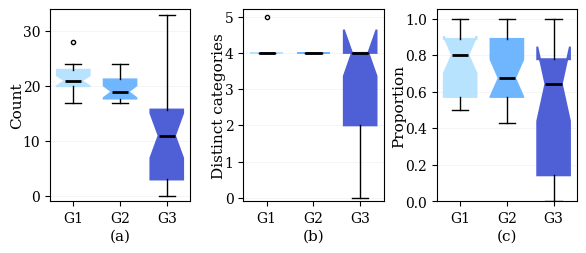

In [20]:

# ============================================================
# RQ1 figure: failure count, failure diversity, and CO failures
# ============================================================
import matplotlib.pyplot as plt
from pathlib import Path

# Create figure output folder.
FIG_DIR = Path("img")
FIG_DIR.mkdir(exist_ok=True)

# Make sure the required columns exist.
required_fig_cols = ["spec_condition", "failure_count", "failure_diversity", "norm_fail_CO"]
missing_fig_cols = [c for c in required_fig_cols if c not in df.columns]
if missing_fig_cols:
    raise ValueError(f"Missing columns needed for RQ1 figure: {missing_fig_cols}")

# Use standard condition order.
plot_df = df.copy()
plot_df["spec_condition"] = plot_df["spec_condition"].astype(str).str.strip()

group_order = ["G1", "G2", "G3"]
existing_groups = [g for g in group_order if g in plot_df["spec_condition"].unique()]
if len(existing_groups) != 3:
    existing_groups = sorted(plot_df["spec_condition"].dropna().unique())

def grouped_values(data, col):
    """Return values by specification group in fixed plotting order."""
    return [
        data.loc[data["spec_condition"] == g, col].dropna().to_numpy()
        for g in existing_groups
    ]

failure_count_data = grouped_values(plot_df, "failure_count")
failure_diversity_data = grouped_values(plot_df, "failure_diversity")
co_proportion_data = grouped_values(plot_df, "norm_fail_CO")

# ICSE-friendly compact style.
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

colors = ["#b7e3ff", "#6fb6ff", "#4f5fd5"]

fig, axes = plt.subplots(1, 3, figsize=(6.8, 3.0))
fig.subplots_adjust(wspace=0.38, bottom=0.24)

def styled_boxplot(ax, data, ylabel, ylim=None):
    positions = [1.00, 1.10, 1.20][:len(data)]

    bp = ax.boxplot(
        data,
        positions=positions,
        notch=True,
        patch_artist=True,
        widths=0.07,
        whis=1.5,
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=3,
        ),
    )

    for patch, color in zip(bp["boxes"], colors[:len(data)]):
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_linewidth(1.4)

    ax.set_ylabel(ylabel, labelpad=-1)
    ax.set_xticks(positions)
    ax.set_xticklabels(existing_groups)
    ax.set_xlim(min(positions) - 0.05, max(positions) + 0.05)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.15)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

# Draw plots.
styled_boxplot(axes[0], failure_count_data, "Count", ylim=(-1, 34))
styled_boxplot(axes[1], failure_diversity_data, "Distinct categories", ylim=(-0.1, 5.2))
styled_boxplot(axes[2], co_proportion_data, "Proportion", ylim=(0, 1.05))

# Panel labels.
for label, ax in zip(["(a)", "(b)", "(c)"], axes):
    ax.text(
        0.5, -0.18, label,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=11,
    )

# Save.
output_pdf = FIG_DIR / "RQ1_boxplot_final.pdf"
fig.savefig(output_pdf, bbox_inches="tight", facecolor="white")
# print(f"Saved figure to: {output_pdf}")

plt.show()
